In [1]:
using ITensors, ITensorMPS
using ProgressMeter
using Plots

The system is quenched with the Ising Hamiltonian with g = 0.7 and evolved up to a
final time T = 4, using a Trotter time step δt = 0.1 (or δt = 0.05 for increased
accuracy). The maximum bond dimension is fixed to χ = 200 throughout. Unless
otherwise stated, local observables are measured at the central site i = N/2.

In [ ]:
Jxx = 1
gz = 0.7
maxdim = 200
cutoff = 1e-10

LL = 50

dt = 0.1
Nt = 4 / 0.1
@show Nt

Nt = 40.0


40.0

We build the Trotterized Time evolution op U(delta t) as a MPO:

$$ e^{iZ/2}e^{iXX}e^{iZ/2} $$

$$U_{XX} = \prod_i e^{-i \delta t X_i X_{i+1}}$$

Euler's formula $e^{i\theta} = \cos\theta + i\sin\theta$:

$$e^{i \alpha X_i X_{i+1}} = \cos(\alpha) (I_i \otimes I_{i+1}) + i \sin(\alpha) (X_i \otimes X_{i+1})$$

 we must build a single-site matrix $W$ for every spin, such that when we multiply $W_1 \cdot W_2$, we get the Euler formula above.

 To get terms like $(I \otimes I)$ and $(X \otimes X)$, we can define $W$ as a $2 \times 2$ matrix living on the virtual links, where the entries are the physical operators $I$ and $X$.

 $$W = \begin{pmatrix} \cos(\alpha) I & \sqrt{i \sin(\alpha) \cos(\alpha)} X \\ \sqrt{i \sin(\alpha) \cos(\alpha)} X & i \sin(\alpha) I \end{pmatrix}$$

In [3]:
function expXX_murg(sites::Vector{<:Index}, Jdt::Number)

    N = length(sites)
    U_XX = MPO(N)

    # bond dimension 2
    link_indices = [Index(2, "Link,l=$(n-1)") for n = 1:N+1]

    for n = 1:N

        # left and right link
        ll = dag(link_indices[n])
        rl = link_indices[n+1]

        I = op(sites, "Id", n)
        X = op(sites, "X", n)

        if n == 1
            U_XX[n] = onehot(rl => 1) * sqrt(cos(Jdt))*I
            U_XX[n] += onehot(rl => 2) * sqrt(im*sin(Jdt))*X
        elseif n == N
            U_XX[n] = onehot(ll => 1) * sqrt(cos(Jdt))*I
            U_XX[n] += onehot(ll => 2) * sqrt(im*sin(Jdt))*X

        else
            U_XX[n] = onehot(ll => 1, rl =>1) * cos(Jdt)*I
            U_XX[n] += onehot(ll => 1, rl =>2) * sqrt(im*sin(Jdt))*sqrt(cos(Jdt)) * X
            U_XX[n] += onehot(ll => 2, rl =>1) * sqrt(im*sin(Jdt))*sqrt(cos(Jdt)) * X
            U_XX[n] += onehot(ll => 2, rl =>2) * im*sin(Jdt)*I
        end 
    end

    return U_XX

end

function expH_ising(sites::Vector{<:Index}, JXX::Number, gz::Number)

    Uxx = expXX_murg(sites, JXX)

    Uz2 = MPO([op(s, "Rz", θ=-gz) for s in sites])

    # Multiply in order: exp(iZ/2)*exp(iXX)*exp(iZ/2)

    U_t = copy(Uz2)
    U_t = apply(Uxx, U_t, alg="naive", truncate=false)
    U_t = apply(Uz2, U_t, alg="naive", truncate=false)

    return U_t
end

expH_ising (generic function with 1 method)

2.3 Part I (3 pts): Expectation value with TEBD

Compute the expectation value of the local operator Zi=N/2(t) up to time T = 4 using
TEBD.

Plot ⟨ZN/2(t)⟩ as a function of time.

In [4]:
ss = siteinds("S=1/2", 50)
psi0 = MPS(ss, "Up")

psi_t = copy(psi0)
Ut = expH_ising(ss, Jxx*dt, gz*dt)

@show maxlinkdim(Ut)

zetas = []
@showprogress for tt=1:Nt
    psi_t = apply(Ut, psi_t; cutoff, maxdim)
    push!(zetas, expect(psi_t, "Z")[div(LL,2)])
end

@show maxlinkdim(psi_t)

maxlinkdim(Ut) = 2


Progress: 100%|█████████████████████████████████████████| Time: 0:01:41


maxlinkdim(psi_t) = 69


69

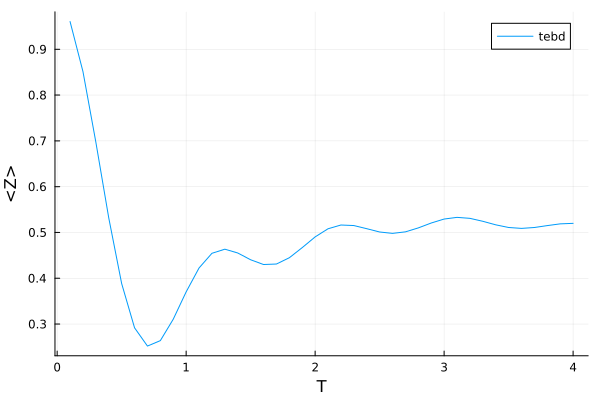

In [5]:
times = 0.1:0.1:4
plot1 = plot(times, zetas, label="tebd", xlabel="T", ylabel="<Z>")

### 2.4 Part II (6 pts): Expectation value via transverse contraction

1. Identify columns of the tensor network as transfer matrices $E$ in MPO form. You may reuse the tensors defined in Part I, keeping in mind that the roles of physical and virtual legs are now exchanged.

2. Initialize left and right boundary states $\langle L_0 |$ and $| R_0 \rangle$ as MPS. Iteratively apply the transfer matrix $E$ from both sides, truncating up to bond dimension $\chi = 200$ if necessary, until reaching the column containing the local operator. This defines the effective states $\langle L |$ and $| R \rangle$.

**Technical remarks:**

* If your MPO tensors are left-right symmetric (this can be done, as we have discussed in class), you may work with a single boundary MPS, since the other is simply its transpose (note: transpose, not the Hermitian conjugate!). Otherwise, just take care to apply the MPO in the correct direction and compute both $| R \rangle$ and $\langle L |$.
* Since the local operator lies deep inside the light cone and here the Lieb–Robinson velocity satisfies $v < 5$, boundary effects are irrelevant for the times considered, so we could treat the system as if it was infinite. Our solution for $\langle L |$ and $| R \rangle$ could then be seen as the result of a "power method", as we have seen in class: we just apply the transfer matrix $E$ many times until convergence is reached - in this context, do you expect the actual choice of the initial boundary MPS to matter? Discuss what you think and why, and check numerically if you're right (you can try e.g. comparing with random MPS at the boundaries).
* Unlike $U(\delta t)$, the transfer matrix $E$ is not unitary. Repeated application of it may thus cause the norm of the MPS to grow or decay exponentially. To have a stable algorithm, you might need to normalize the MPS after each step; any remaining normalization factors can be handled with the following prescription for computing the expectation value.

3. Compute the expectation value as:
$$\langle O(t) \rangle = \frac{\langle L | E_{op} | R \rangle}{\langle L | E | R \rangle} \quad (5)$$
where $E_{op}$ denotes the column containing the local operator and $E$ the corresponding column without it. Verify that the result agrees with Part I.

In [6]:
# inner() conjugates so we undo it
function expval_lr(left::MPS, E::MPO, right::MPS)
    overlap = ITensor(1.0)
    for kk in eachindex(left)
        overlap *= left'[kk]
        overlap *= E[kk]
        overlap *= right[kk]
        @assert ndims(overlap) < 4
    end
    return scalar(overlap)
end

expval_lr (generic function with 1 method)

In [7]:
# Columns built from spatial MPO - they are 2Nt sites each (forward + backward)
function build_E(time_sites::Vector{<:Index}, Ut::MPO, init_state::Vector)
    @assert length(Ut) > 2
    
    # Extract the old spatial indices from the time-evolution MPO
    llink = linkind(Ut, 1)
    rlink = linkind(Ut, 2)
    phys_ind = siteind(Ut, 2; plev=0)
    
    @assert iseven(length(time_sites))
    Nt = div(length(time_sites), 2)
    
    EE = MPO(2*Nt)
    
    # Create new virtual links for the spatial transfer matrix
    time_links = [Index(dim(phys_ind), "Time,Link,l=$(kk-1)") for kk = 1:2*Nt+1]
    
    for ii in 1:Nt
        # Rotate inds 90 deg for U(\delta t)
        EE[ii] = replaceinds(Ut[2], 
            (llink, rlink, phys_ind, phys_ind') => 
            (time_sites[ii], time_sites[ii]', time_links[ii], time_links[ii+1])
        )
    end
    
    for ii in Nt+1:2*Nt
        # Rotate inds 90 deg for U^\dagger(\delta t)
        EE[ii] = replaceinds(dag(Ut[2]), 
            (llink, rlink, phys_ind, phys_ind') => 
            (time_sites[ii], time_sites[ii]', time_links[ii], time_links[ii+1])
        )
    end
    
    # Cap the boundaries with the initial states
    tensor_init_state = ITensor(init_state, time_links[1])
    tensor_fin_state = ITensor(conj(init_state), time_links[end])
    
    EE[1] *= tensor_init_state
    EE[end] *= tensor_fin_state
    
    return EE
end

build_E (generic function with 1 method)

In [8]:
function vn_entanglement_entropy(psi::MPS)

    workpsi = orthogonalize(psi,1)
    workpsi = workpsi/norm(workpsi)
    ents_vn = Vector{Float64}(undef, length(workpsi)-1)

    for bond=1:length(workpsi)-1
        orthogonalize!(psi, bond)  # move orthogonality center as we sweep
        _, S, _ = svd(psi[bond], uniqueinds(psi[bond],psi[bond+1])) # compares the tensor at bond with the tensor at bond+1 and returns the indices that belong only to the left side (the physical leg and the left-virtual leg)
        SvN = 0.0
        for n in 1:dim(S, 1)
            p = S[n, n]^2
            if p > 1e-12
                SvN -= p * log(p)
            end
        end
        ents_vn[bond] = SvN
    end

    return ents_vn
end

vn_entanglement_entropy (generic function with 1 method)

In [ ]:
evs_tr = []
times_tr = []
ents_tr = []

@showprogress for ttt = 5:5:40
    # 1. Prepare the vertical column
    time_sites = addtags(siteinds("S=1/2", 2*ttt), "time")
    Ecol = build_E(time_sites, Ut, [1.0, 0.0])
    Ecol_op = copy(Ecol)
    
    # 2. The Power Method (Spatial Contraction)
    right = random_mps(time_sites, linkdims=2)
    @showprogress for jj = 1:div(LL,2)
        right = apply(Ecol, right)
        right = normalize(right)
    end
    @show maxlinkdim(right)
    
    # 3. Inserting the Local Operator
    sz = ITensor([1.0 0.0; 0.0 -1.0], linkind(Ecol, ttt), linkind(Ecol, ttt)')
    Ecol_op[ttt] = noprime(sz * Ecol_op[ttt], "Link")
    
    # 4. The Measurement
    # We have left-right symmetry here so we only need to compute the right boundary
    val = expval_lr(right, Ecol_op, right) / expval_lr(right, Ecol, right)
    
    push!(evs_tr, val)
    push!(times_tr, ttt * 0.1)
    push!(ents_tr, vn_entanglement_entropy(right))
end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:01


maxlinkdim(right) = 6


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


maxlinkdim(right) = 8


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


...

maxlinkdim(right) = 42


Progress: 100%|█████████████████████████████████████████| Time: 0:00:25


maxlinkdim(right) = 62


Progress: 100%|█████████████████████████████████████████| Time: 0:00:50


maxlinkdim(right) = 85


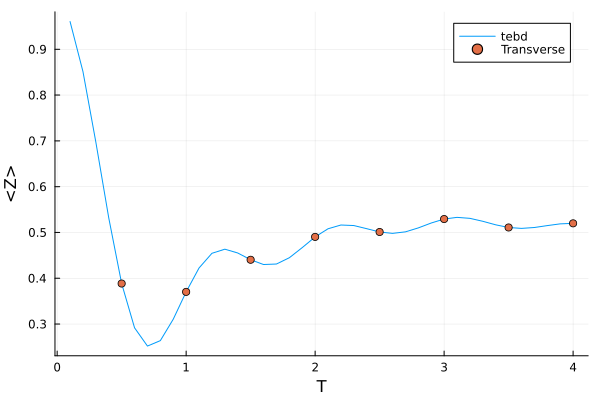

In [10]:
scatter!(plot1, times_tr, real(evs_tr), label="Transverse")

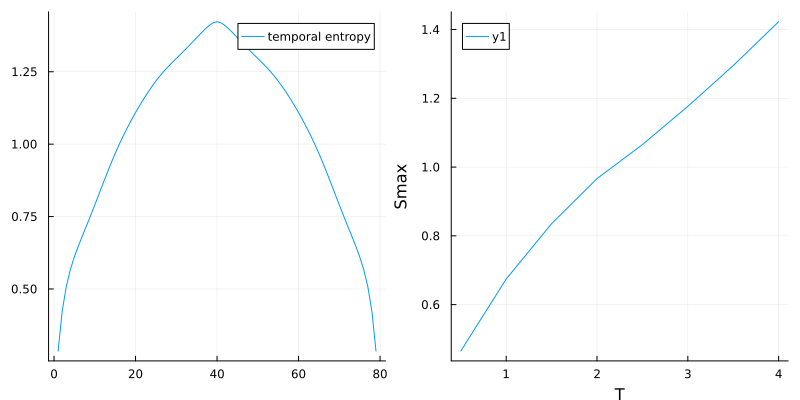

In [11]:
p1 = plot(ents_tr[end], label="temporal entropy")
p2 = plot(times_tr, maximum.(ents_tr), xlabel="T", ylabel="Smax")
plot(p1,p2, size=(800, 400))

Now let us use the ITransverse package

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter C:\Users\jmarq\.julia\packages\ProgressMeter\N660J\src\ProgressMeter.jl:607
[cone(v=1)|RTM_LR] [psi0 >> Op] cutoff=1.0e-10, maxdim=200) 100% Time: 0:00:09 ( 0.23  s/it)
   Info: [40] χ=19, (L|R) = 0.9999983545806054 + 1.0408340855860843e-16im 


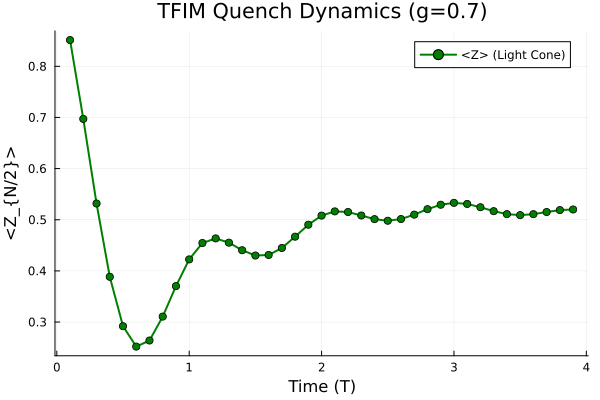

In [ ]:
using ITensors, ITensorMPS
using ITransverse
using ITransverse.ITenUtils
using Plots

# System Parameters
Jxx = 1.0; gz = 0.7; hx = 0.0
dt = 0.1; T_max = 4.0
maxdim = 200; cutoff = 1e-10

# Setup the Model and Extract Index
mp = IsingParams(Jxx, gz, hx)
s = getfield(mp, 4)

# Boundary State Initialization
bl = ITensor(ComplexF64, s)
bl[s => 1] = 1.0 + 0.0im 

# Build Folded Blocks
tp = tMPOParams(dt, ITransverse.expH_ising_murg, mp, 0, bl)
fb = FoldtMPOBlocks(tp)

# 4. Setup Cone Parameters
t_params = TruncParams(cutoff, maxdim, "left")

cp = ConeParams(
    truncp = t_params,
    opt_method = "RTM_LR",       
    optimize_op = [1.0, 0.0, 0.0, -1.0],  # Raw numeric vector for Z
    vwidth = 1                   
)

# THE FIX: Notice the trailing comma after the function. It is mandatory.
chk = DoCheckpoint(
    "cp_cone_quench.jld2";
    params=tp,
    save_at=0, 
    observables = (
        Z = s -> compute_expvals(s.L, s.R, ["Z"], s.b),
    )
)

# 5. Run Light Cone Evolution
init_mps = init_cone(fb, 1)
Nt_final = Int(round(T_max / dt))

# Pass BOTH cp (ConeParams) and chk (DoCheckpoint) into run_cone
L_final, R_final, checkpt = run_cone(init_mps, fb, cp, chk, Nt_final)

# 6. Extract and Plot
z_vals_raw = checkpt.history[:Z]

# THE FIX: 'v' is a dictionary, so we must extract the value using the string key "Z", not the index 1.
z_vals = [real(v["Z"]) for v in z_vals_raw]

times_plot = [n * dt for n in 1:length(z_vals)]

plot(times_plot, z_vals, 
     label="<Z> (Light Cone)", 
     xlabel="Time (T)", 
     ylabel="<Z_{N/2}>", 
     lw=2, color=:green,
     marker=:circle,
     title="TFIM Quench Dynamics (g=0.7)")